# Mineração de Processos na Construção Civil
## Análise de Fluxo de Obra com ProM e Python

---

## Objetivos da Aula

Ao final desta aula, o aluno deve ser capaz de:

1. Compreender os fundamentos da Mineração de Processos (*Process Mining*) e sua aplicabilidade em projetos de construção civil.
2. Gerar e manipular logs de eventos no formato _XES_, padrão aceito pelo ProM.
3. Executar os algoritmos **Alpha Miner**, **Heuristics Miner** e **Inductive Miner** via Python (`pm4py`) para reproduzir o mesmo pipeline do ProM.
4. Interpretar redes de Petri e mapas de processo resultantes.
5. Realizar análise de conformidade (*conformance checking*) entre o processo descoberto e um modelo normativo.
6. Discussão crítica dos resultados e implicações para gestão de obras.

---

## 1. Por que Mineração de Processos na Construção Civil?

Projetos de construção civil são notoriamente complexos: múltiplos empreiteiros, sequenciamentos rígidos de atividades (contrapiso antes do revestimento, estrutura antes da alvenaria), interdependências entre disciplinas (civil, elétrica, hidráulica) e restrições de prazo que tornam qualquer desvio custoso.

Sistemas como ERP de obras, aplicativos de apontamento de mão de obra e plataformas BIM 4D registram automaticamente **quando** cada atividade foi iniciada e concluída por **qual equipe** em **qual pavimento ou frente de serviço**. Esses registros — compostos pelo identificador do local, o nome da tarefa e o carimbo de data e hora — formam a matéria-prima essencial da Mineração de Processos, os **logs de eventos**, a partir dos quais a tecnologia extrai modelos de processo que descrevem visualmente como o trabalho efetivamente aconteceu no canteiro, e não como o planejamento dizia que aconteceria. Assim, ao confrontar esse modelo real descoberto com o modelo normativo (planejado), **o sistema revela instantaneamente gargalos crônicos, retrabalhos dispendiosos e inversões perigosas de sequência na obra**.

### 1.1 Conceitos Essenciais

| Conceito | Definição |
|---|---|
| **Caso (_Case_)** | Uma instância do processo — ex.: execução do Apartamento 301 |
| **Evento (_Event_)** | Um registro de que uma atividade ocorreu em determinado instante |
| **Atividade (_Activity_)** | A tarefa realizada — ex.: *Impermeabilização*, *Revestimento Cerâmico* |
| **_Timestamp_** | Data e hora do evento |
| **_Log_ de Eventos** | Conjunto de todos os casos e seus eventos |
| **Rede de Petri** | Formalismo matemático usado para representar o processo descoberto |
| **_Fitness_** | Grau em que o log é reproduzível pelo modelo |
| **_Precision_** | Grau em que o modelo não permite comportamentos ausentes no log |

---

## 2. Exemplo de Aplicação: Edifício Residencial — Ciclo de Acabamento

Consideremos um edifício residencial com 20 apartamentos (unidades), cada um passando por 8 atividades de acabamento em sequência planejada:

```
Impermeabilização → Revestimento Parede → Revestimento Piso → Instalação Elétrica
    → Instalação Hidráulica → Pintura → Marcenaria → Vistoria Final
```

Na prática, obras sofrem interrupções, retrabalhos e alterações de sequência. O log gerado a seguir simulará esse cenário realista.

---

## 3. Instalação das Bibliotecas

In [1]:
# Instalação — execute apenas uma vez
# pm4py é a biblioteca Python que implementa os mesmos algoritmos do ProM
%pip install pm4py matplotlib pandas graphviz --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ==============================================================================
# 1. MANIPULAÇÃO DE DADOS, MATEMÁTICA E SUPRESSÃO DE AVISOS
# ==============================================================================
import pandas as pd              # Estrutura a matéria-prima (logs de eventos) em DataFrames
import numpy as np               # Operações matemáticas e geração de dados numéricos
import matplotlib.pyplot as plt  # Renderização de gráficos estatísticos de desempenho
import matplotlib.patches as mpatches # Criação de legendas customizadas para os fluxos
import warnings                  # Controle de alertas do sistema
warnings.filterwarnings('ignore') # Ignora avisos de depreciação para manter o output limpo

# ==============================================================================
# 2. FRAMEWORK PM4PY (MINERAÇÃO DE PROCESSOS)
# ==============================================================================
import pm4py # Biblioteca principal de Process Mining

# Objetos base e conversores de formato
from pm4py.objects.log.obj import EventLog, Trace, Event # Estruturas nativas de log
from pm4py.objects.conversion.log import converter as log_converter # Conversor DataFrame -> EventLog

# Algoritmos de Descoberta de Processos (Do mais rígido ao mais robusto)
from pm4py.algo.discovery.alpha import algorithm as alpha_miner         # Algoritmo Alfa clássico
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner # Mineiro heurístico (ignora ruídos)
from pm4py.algo.discovery.inductive import algorithm as inductive_miner   # Mineiro indutivo (garante modelos válidos)

# Algoritmo de Análise de Conformidade (Compliance)
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay # Compara o real com o planejado

# Visualizadores gráficos das redes descobertas
from pm4py.visualization.petri_net import visualizer as pn_visualizer   # Renderiza Redes de Petri
from pm4py.visualization.process_tree import visualizer as pt_visualizer # Renderiza Árvores de Processos
from pm4py.visualization.heuristics_net import visualizer as hn_visualizer # Renderiza Redes Heurísticas

# Estatísticas e Filtros de Variantes (Caminhos da Obra)
from pm4py.statistics.traces.generic.log import case_statistics # Extrai métricas de tempo e recorrência
from pm4py.algo.filtering.log.variants import variants_filter   # Agrupa e filtra os fluxos mais comuns

# ==============================================================================
# 3. MANIPULAÇÃO DE TEMPO E GERADORES SINTÉTICOS
# ==============================================================================
from datetime import datetime, timedelta # Manipulação de datas e prazos de cura/secagem
import random                            # Geração de desvios e atrasos aleatórios

# ==============================================================================
# 4. CONFIGURAÇÃO DE REPRODUTIBILIDADE E VERIFICAÇÃO
# ==============================================================================
random.seed(42)   # Garante que os desvios gerados aleatoriamente sejam sempre os mesmos
np.random.seed(42) # Fixa a semente do NumPy para consistência nos dados estruturais

print(f"pm4py versão: {pm4py.__version__}")
print("Bibliotecas carregadas com sucesso.")


pm4py versão: 2.7.22.4
Bibliotecas carregadas com sucesso.


---

## 4. Geração do Log de Eventos Sintético (Cenário Realista de Obra)

O log simula 20 apartamentos com variações realistas:
- **Retrabalho**: ~20% das unidades repetem *Revestimento Piso*
- **Inversão de sequência**: ~15% executam *Pintura* antes de *Marcenaria* (ordem correta) mas intercalam *Instalação Elétrica* após *Instalação Hidráulica* (ordem invertida)
- **Atividade pulada**: ~10% das unidades omitem a *Vistoria Final* (não conformidade grave)
- **Duração variável**: cada atividade tem duração estocástica

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# ==============================================================================
# 1. CONFIGURAÇÃO DO MODELO NORMATIVO (O PLANEJAMENTO TEÓRICO DA OBRA)
# ==============================================================================
ATIVIDADES = [
    ('Impermeabilizacao',     2), 
    ('Revestimento_Parede',   4), 
    ('Revestimento_Piso',     3), 
    ('Instalacao_Eletrica',   3), 
    ('Instalacao_Hidraulica', 3), 
    ('Pintura',               4), 
    ('Marcenaria',            5), 
    ('Vistoria_Final',        1), 
]

RECURSOS = {
    'Impermeabilizacao':     ['Equipe_Impermeabilizacao'],
    'Revestimento_Parede':   ['Equipe_Ceramica_A', 'Equipe_Ceramica_B'], 
    'Revestimento_Piso':     ['Equipe_Ceramica_A', 'Equipe_Ceramica_B'], 
    'Instalacao_Eletrica':   ['Equipe_Eletrica'],
    'Instalacao_Hidraulica': ['Equipe_Hidraulica'],
    'Pintura':               ['Equipe_Pintura_A', 'Equipe_Pintura_B'], 
    'Marcenaria':            ['Equipe_Marcenaria'],
    'Vistoria_Final':        ['Engenheiro_Residente'],
}

# ==============================================================================
# 2. SIMULAÇÃO (GERADOR DE DESVIOS TOTALMENTE DINÂMICO)
# ==============================================================================
def gerar_trace(apt_id, data_inicio):
    eventos = []
    ts = data_inicio
    sequencia = list(ATIVIDADES) 

    # MUDOU: Inversão Geral de Sequência (Ocorre em ~20% dos casos)
    if random.random() < 0.20:
        idx_e = next(i for i,a in enumerate(sequencia) if a[0]=='Instalacao_Eletrica')
        idx_h = next(i for i,a in enumerate(sequencia) if a[0]=='Instalacao_Hidraulica')
        sequencia[idx_e], sequencia[idx_h] = sequencia[idx_h], sequencia[idx_e]

    # LOOP PRINCIPAL: Processando cada atividade da sequência
    for atividade, dur_media in sequencia:
        
        # MUDOU: Falha de Registro Geral (Ocorre em ~5% de QUALQUER atividade)
        # Se o gatilho disparar, a atividade acontece na obra, mas o registro é perdido (Omissão).
        if random.random() < 0.05:
            continue # Pula o registro do evento atual no log, fazendo o número cair abaixo de 20

        dur = max(1, int(np.random.normal(dur_media, dur_media * 0.4)))
        recurso = random.choice(RECURSOS[atividade])

        eventos.append({
            'case:concept:name': f'APT_{apt_id:02d}',     
            'concept:name':      atividade,               
            'time:timestamp':    ts,                      
            'org:resource':      recurso,                 
            'lifecycle:transition': 'complete',           
        })
        ts += timedelta(days=dur)

        # --------------------------------------------------------------------------
        # NOVO: Erros específicos para destravar as atividades que estavam fixas
        # --------------------------------------------------------------------------

        # 1. Falha no Teste de Estanqueidade (~15% de chance) -> Refazer Impermeabilização
        if atividade == 'Impermeabilizacao' and random.random() < 0.15:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Impermeabilizacao',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Impermeabilizacao']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2)

        # 2. Erro de Paginação ou Peças Quebradas (~20% de chance) -> Refazer Revestimento Parede
        if atividade == 'Revestimento_Parede' and random.random() < 0.20:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Revestimento_Parede',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Revestimento_Parede']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2)

        # 3. Vazamento em Junções Hidráulicas (~15% de chance) -> Retrabalho na Hidráulica
        if atividade == 'Instalacao_Hidraulica' and random.random() < 0.15:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Instalacao_Hidraulica',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Instalacao_Hidraulica']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=1)

        # 4. Furto de Fiação ou Ajuste de Tomada (~10% de chance) -> Retrabalho na Elétrica
        if atividade == 'Instalacao_Eletrica' and random.random() < 0.10:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Instalacao_Eletrica',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Instalacao_Eletrica']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=1)

        # 5. Erro nas Dimensões dos Módulos (~15% de chance) -> Ajuste de Marcenaria
        if atividade == 'Marcenaria' and random.random() < 0.15:
            ts += timedelta(days=2) # Tempo de ajuste na oficina
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Marcenaria',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Marcenaria']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2)

        # Retrabalhos originais mantidos (Piso e Pintura)
        if atividade == 'Revestimento_Piso' and random.random() < 0.25:
            ts += timedelta(days=1)  
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Revestimento_Piso',  
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Revestimento_Piso']), 
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2) 

        if atividade == 'Marcenaria' and random.random() < 0.20:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Pintura', 
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Pintura']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2)

    # Vistoria Final Omissão mantida
    if random.random() < 0.15:
        eventos = [e for e in eventos if e['concept:name'] != 'Vistoria_Final']

    return eventos

# ==============================================================================
# 3. GERAÇÃO E CONSOLIDAÇÃO DO LOG DE EVENTOS DA OBRA INTEIRA
# ==============================================================================
todos_eventos = []
data_inicio_obra = datetime(2026, 1, 1)

for apt in range(1, 21):
    offset = timedelta(days=random.randint(0, 30))
    todos_eventos.extend(gerar_trace(apt, data_inicio_obra + offset))

df_log = pd.DataFrame(todos_eventos)
df_log['time:timestamp'] = pd.to_datetime(df_log['time:timestamp'])
df_log = df_log.sort_values(['case:concept:name','time:timestamp']).reset_index(drop=True)

print(f"Total de eventos: {len(df_log)}")
print(f"Total de casos (apartamentos): {df_log['case:concept:name'].nunique()}")
print(f"\nDistribuição dinâmica de atividades nesta rodada:")
print(df_log['concept:name'].value_counts().to_string())


Total de eventos: 174
Total de casos (apartamentos): 20

Distribuição dinâmica de atividades nesta rodada:
concept:name
Revestimento_Piso        27
Pintura                  23
Instalacao_Eletrica      23
Impermeabilizacao        22
Marcenaria               22
Revestimento_Parede      21
Instalacao_Hidraulica    19
Vistoria_Final           17


### 4.1 Visualização Exploratória do Log

Figura salva com sucesso em: img/aula_construcao/gantt_obra.png


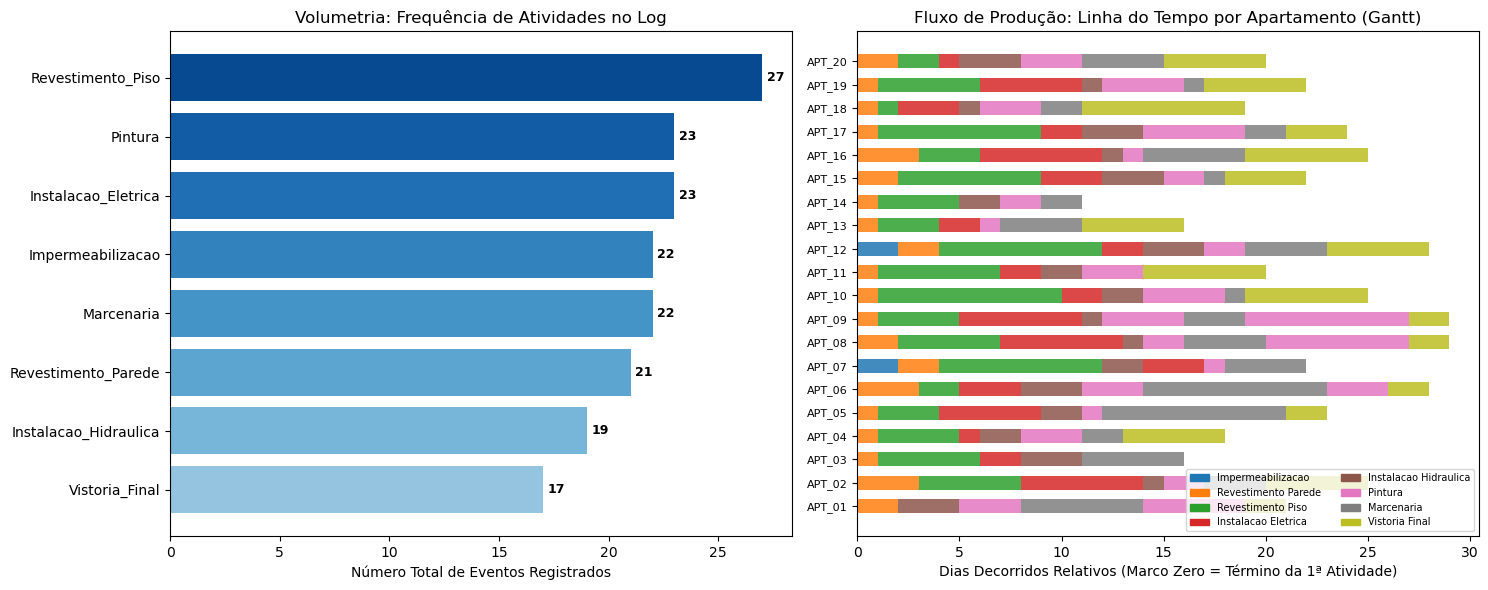

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Configura a área de desenho com dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ==============================================================================
# GRÁFICO 1: FREQUÊNCIA DE ATIVIDADES (Volumetria do Canteiro)
# ==============================================================================
# Conta a ocorrência de cada atividade no log (exõe retrabalhos e omissões)
contagem = df_log['concept:name'].value_counts()

# Cria um degradê de cores azul (do escuro para o claro) baseado no total de tarefas
cores = plt.cm.Blues(np.linspace(0.4, 0.9, len(contagem)))

# Plota as barras horizontais invertendo a paleta para que o maior valor fique mais escuro
axes[0].barh(contagem.index, contagem.values, color=cores[::-1])
axes[0].set_xlabel('Número Total de Eventos Registrados')
axes[0].set_title('Volumetria: Frequência de Atividades no Log')
axes[0].invert_yaxis() # Mantém a atividade mais frequente no topo do gráfico

# Adiciona os rótulos numéricos exatos na ponta de cada barra para facilitar a leitura
for i, v in enumerate(contagem.values):
    axes[0].text(v + 0.2, i, str(v), va='center', fontsize=9, fontweight='bold')

# ==============================================================================
# GRÁFICO 2: LINHA DO TEMPO RECONSTRUÍDA (Gantt Realista por Apartamento)
# ==============================================================================
# Extrai e ordena a lista de apartamentos únicos (Casos)
apt_list = sorted(df_log['case:concept:name'].unique())

# Mapeia uma cor única e estática para cada atividade baseada na lista teórica original
atividade_cores = {
    a: plt.cm.tab10(i / len(ATIVIDADES)) for i, (a, _) in enumerate(ATIVIDADES)
}

# Varre cada apartamento para desenhar sua respectiva linha cronológica
for y_idx, apt in enumerate(apt_list):
    # Isola os eventos do apartamento atual e garante a ordenação cronológica perfeita
    eventos_apt = df_log[df_log['case:concept:name'] == apt].sort_values('time:timestamp').copy()
    
    # Define o marco zero (o primeiro registro de término do apartamento)
    ts_min = eventos_apt['time:timestamp'].min()
    
    # CORREÇÃO CRÍTICA: Inicializa o ponteiro de início da primeira atividade da linha como 0
    start_day = 0 
    
    for _, row in eventos_apt.iterrows():
        # Calcula em qual dia relativo o evento atual terminou
        end_day = (row['time:timestamp'] - ts_min).days
        
        # Se por flutuação estatística o end_day for menor que o start_day, força a duração mínima de 1 dia
        if end_day < start_day:
            end_day = start_day + 1
            
        # A duração real da barra é a diferença entre o dia que acabou e o dia que começou
        duration = end_day - start_day
        
        # Recupera a cor da atividade (aplica cinza caso surja alguma atividade não mapeada)
        cor = atividade_cores.get(row['concept:name'], 'gray')
        
        # Plota a barra: left é onde começou, width é a duração real calculada
        axes[1].barh(y_idx, width=duration, left=start_day, height=0.6, color=cor, alpha=0.85)
        
        # AVANÇA O PONTEIRO: O início da próxima atividade será exatamente o término desta
        start_day = end_day

# Configurações de eixo e legenda do Gantt
axes[1].set_yticks(range(len(apt_list)))
axes[1].set_yticklabels(apt_list, fontsize=8)
axes[1].set_xlabel('Dias Decorridos Relativos (Marco Zero = Término da 1ª Atividade)')
axes[1].set_title('Fluxo de Produção: Linha do Tempo por Apartamento (Gantt)')

# Cria as legendas customizadas removendo os underlines dos nomes das tarefas
patches = [mpatches.Patch(color=atividade_cores[a], label=a.replace('_',' '))
           for a, _ in ATIVIDADES if a in atividade_cores]
axes[1].legend(handles=patches, loc='lower right', fontsize=7, ncol=2, frameon=True)

# Ajusta o espaçamento das margens para evitar cortes nos textos
plt.tight_layout()

# Salva o arquivo final em alta resolução (DPI 150) eliminando bordas brancas sobressalentes
# O 'r' antes das aspas garante que o Windows entenda as barras invertidas corretamente
# Caminho relativo direto a partir da pasta 'mineracaoProcessos' onde está o seu notebook
caminho_salvamento = r"img/aula_construcao/gantt_obra.png"

# Cria a pasta 'aula_construcao' caso ela ainda não exista no diretório
os.makedirs(os.path.dirname(caminho_salvamento), exist_ok=True)

# Salva o gráfico antes do encerramento da figura pelo plt.show()
plt.savefig(caminho_salvamento, dpi=150, bbox_inches='tight')
print(f"Figura salva com sucesso em: {caminho_salvamento}")
plt.show()

---

## 5. Exportação para XES e Carregamento no pm4py

O formato **XES** (*eXtensible Event Stream*) é o padrão IEEE 1849 para logs de eventos. O ProM importa nativamente arquivos `.xes`. A biblioteca `pm4py` escreve e lê XES com a mesma estrutura, permitindo que o notebook e o ProM utilizem **exatamente o mesmo arquivo**.

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from collections import defaultdict

# ==== GERAÇÃO DO df_log (igual ao seu) ====
# ... (mantenha seu código de geração aqui) ...

# ==== EXPORTA XES MANUALMENTE (sem pm4py.write_xes) ====
def df_to_xes(df, filepath):
    lines = ['<?xml version="1.0" encoding="UTF-8" ?>',
             '<log xes.version="1.0" xmlns="http://www.xes-standard.org/">',
             '  <extension name="Concept" prefix="concept" uri="http://www.xes-standard.org/concept.xesext"/>',
             '  <extension name="Time" prefix="time" uri="http://www.xes-standard.org/time.xesext"/>',
             '  <extension name="Organizational" prefix="org" uri="http://www.xes-standard.org/org.xesext"/>']
    
    for case_id, group in df.groupby('case:concept:name'):
        lines.append(f'  <trace>')
        lines.append(f'    <string key="concept:name" value="{case_id}"/>')
        for _, row in group.iterrows():
            ts = row['time:timestamp'].strftime('%Y-%m-%dT%H:%M:%S.000+00:00')
            lines.append(f'    <event>')
            lines.append(f'      <string key="concept:name" value="{row["concept:name"]}"/>')
            lines.append(f'      <date key="time:timestamp" value="{ts}"/>')
            lines.append(f'      <string key="org:resource" value="{row["org:resource"]}"/>')
            lines.append(f'      <string key="lifecycle:transition" value="{row["lifecycle:transition"]}"/>')
            lines.append(f'    </event>')
        lines.append(f'  </trace>')
    
    lines.append('</log>')
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

df_to_xes(df_log, 'obra_residencial.xes')
print("XES exportado com sucesso")

# ==== VARIANTES DIRETO DO df_log (sem pm4py) ====
variantes_dict = defaultdict(list)
for case_id, group in df_log.sort_values('time:timestamp').groupby('case:concept:name'):
    seq = tuple(group['concept:name'].tolist())
    variantes_dict[seq].append(case_id)

variantes_ordenadas = sorted(variantes_dict.items(), key=lambda x: len(x[1]), reverse=True)

print(f"\nTotal de variantes identificadas: {len(variantes_ordenadas)}\n")
print(f"{'#':<4} {'Frequência':<12} Sequência de Atividades")
print("-" * 100)
for i, (seq, cases) in enumerate(variantes_ordenadas, 1):
    ativs = ' → '.join([str(a).replace('_', ' ') for a in seq])
    print(f"{i:<4} {len(cases):<12} {ativs}")

print()
variante_principal = variantes_ordenadas[0]
print(f"Variante mais frequente ({len(variante_principal[1])} casos — processo dominante):")
print(' → '.join([str(a).replace('_', ' ') for a in variante_principal[0]]))

XES exportado com sucesso

Total de variantes identificadas: 14

#    Frequência   Sequência de Atividades
----------------------------------------------------------------------------------------------------
1    4            Impermeabilizacao → Revestimento Parede → Revestimento Piso → Instalacao Eletrica → Instalacao Hidraulica → Pintura → Marcenaria → Vistoria Final
2    3            Impermeabilizacao → Revestimento Parede → Revestimento Piso → Instalacao Eletrica → Instalacao Eletrica → Instalacao Hidraulica → Pintura → Marcenaria → Vistoria Final
3    2            Impermeabilizacao → Revestimento Parede → Revestimento Piso → Revestimento Piso → Instalacao Eletrica → Instalacao Hidraulica → Pintura → Marcenaria → Vistoria Final
4    1            Impermeabilizacao → Revestimento Parede → Instalacao Hidraulica → Pintura → Marcenaria → Pintura → Vistoria Final
5    1            Impermeabilizacao → Revestimento Parede → Revestimento Piso → Revestimento Piso → Instalacao Eletrica → Inst

### 5.1 Como abrir o arquivo XES no ProM

> **Passo a passo — ProM 6.x (GUI)**
>
> 1. Abra o **ProM 6** (Java, disponível em [https://www.promtools.org](https://www.promtools.org)).
> 2. No painel *Workspace*, clique em **Import** → selecione `obra_residencial.xes`.
> 3. O ProM carregará o log e exibirá o resumo: número de traces, eventos e variantes.
> 4. Com o log selecionado no Workspace, clique em **Analyse** para acessar os algoritmos de descoberta.
>
> O restante desta aula reproduz no Python os mesmos resultados que você obteria no ProM, com as mesmas interpretações.

---

## 6. Análise de Variantes

Variantes (*variants*) são as sequências únicas de atividades observadas no log. Um log com poucas variantes indica processo padronizado; muitas variantes indicam alta variabilidade operacional.

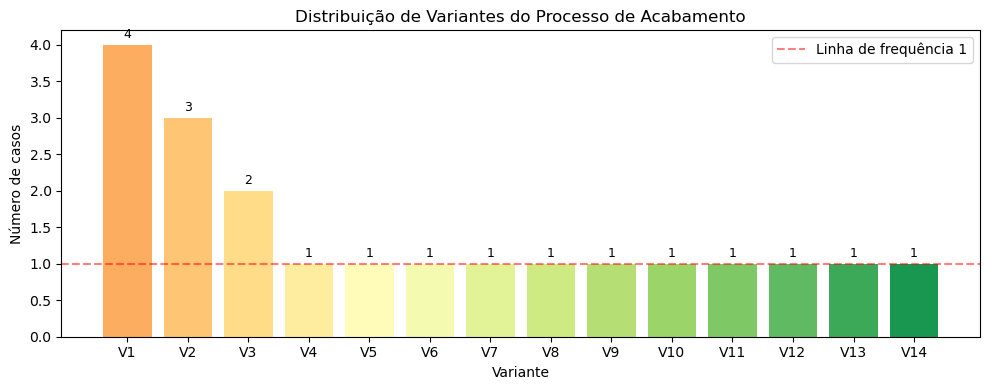

DETALHAMENTO DE CADA VARIANTE


V1 — 4 caso(s): APT_04, APT_15, APT_18, APT_20
Sequência:
   1. Impermeabilizacao
   2. Revestimento Parede
   3. Revestimento Piso
   4. Instalacao Eletrica
   5. Instalacao Hidraulica
   6. Pintura
   7. Marcenaria
   8. Vistoria Final
----------------------------------------------------------------------------------------------------

V2 — 3 caso(s): APT_02, APT_16, APT_19
Sequência:
   1. Impermeabilizacao
   2. Revestimento Parede
   3. Revestimento Piso
   4. Instalacao Eletrica
   5. Instalacao Eletrica
   6. Instalacao Hidraulica
   7. Pintura
   8. Marcenaria
   9. Vistoria Final
----------------------------------------------------------------------------------------------------

V3 — 2 caso(s): APT_10, APT_17
Sequência:
   1. Impermeabilizacao
   2. Revestimento Parede
   3. Revestimento Piso
   4. Revestimento Piso
   5. Instalacao Eletrica
   6. Instalacao Hidraulica
   7. Pintura
   8. Marcenaria
   9. Vistoria Final
------------------------

In [ ]:
# Gráfico de distribuição de variantes
freqs = [len(t) for _, t in variantes_ordenadas]
labels = [f"V{i+1}" for i in range(len(freqs))]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, freqs, color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(freqs))))
ax.set_xlabel('Variante')
ax.set_ylabel('Número de casos')
ax.set_title('Distribuição de Variantes do Processo de Acabamento')
for bar, freq in zip(bars, freqs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(freq), ha='center', va='bottom', fontsize=9)
ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Linha de frequência 1')
ax.legend()
plt.tight_layout()
plt.savefig('variantes.png', dpi=150, bbox_inches='tight')
plt.show()



In [11]:
print("DETALHAMENTO DE CADA VARIANTE\n")
print("=" * 100)

for i, (seq, cases) in enumerate(variantes_ordenadas, 1):
    print(f"\nV{i} — {len(cases)} caso(s): {', '.join(cases)}")
    print("Sequência:")
    for j, ativ in enumerate(seq, 1):
        print(f"  {j:>2}. {ativ.replace('_', ' ')}")
    print("-" * 100)

DETALHAMENTO DE CADA VARIANTE


V1 — 4 caso(s): APT_04, APT_15, APT_18, APT_20
Sequência:
   1. Impermeabilizacao
   2. Revestimento Parede
   3. Revestimento Piso
   4. Instalacao Eletrica
   5. Instalacao Hidraulica
   6. Pintura
   7. Marcenaria
   8. Vistoria Final
----------------------------------------------------------------------------------------------------

V2 — 3 caso(s): APT_02, APT_16, APT_19
Sequência:
   1. Impermeabilizacao
   2. Revestimento Parede
   3. Revestimento Piso
   4. Instalacao Eletrica
   5. Instalacao Eletrica
   6. Instalacao Hidraulica
   7. Pintura
   8. Marcenaria
   9. Vistoria Final
----------------------------------------------------------------------------------------------------

V3 — 2 caso(s): APT_10, APT_17
Sequência:
   1. Impermeabilizacao
   2. Revestimento Parede
   3. Revestimento Piso
   4. Revestimento Piso
   5. Instalacao Eletrica
   6. Instalacao Hidraulica
   7. Pintura
   8. Marcenaria
   9. Vistoria Final
------------------------

**Discussão:** A existência de múltiplas variantes já indica que o processo executado não é idêntico ao planejado. Variantes com baixa frequência merecem investigação prioritária — podem representar erros de sequenciamento ou desvios críticos de qualidade.

---

## 7. Descoberta de Processos — Alpha Miner

### 7.1 Fundamentos do Alpha Miner

O **Alpha Miner** (van der Aalst et al., 2004) é o algoritmo clássico de descoberta de processos. Ele analisa as **relações de ordenação** entre atividades no log:

| Relação | Símbolo | Significado |
|---|---|---|
| Sequência | $a > b$ | $a$ ocorre diretamente antes de $b$ |
| Causalidade | $a \to b$ | $a$ causa $b$ (sempre precedente) |
| Paralelo | $a \|\| b$ | $a$ e $b$ ocorrem em qualquer ordem |
| Sem relação | $a \# b$ | $a$ e $b$ nunca aparecem no mesmo trace |

O resultado é uma **Rede de Petri** com lugares (*places*) e transições (*transitions*).

### 7.2 Como executar no ProM

> 1. Com o log carregado, clique em **Analyse**.
> 2. Na barra de busca de plugins, digite **Alpha Miner**.
> 3. Selecione *Mine with Alpha Miner* e clique **Start**.
> 4. O ProM exibirá a Rede de Petri resultante.
> 5. Use o botão **Export** para salvar a rede no formato PNML.

### 7.3 Execução Python (equivalente ao ProM)

In [ ]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

# Alpha Miner
print("Executando Alpha Miner...")
net_alpha, im_alpha, fm_alpha = alpha_miner.apply(log)

print(f"Rede de Petri descoberta (Alpha Miner):")
print(f"  Transições (atividades): {len(net_alpha.transitions)}")
print(f"  Lugares (places):        {len(net_alpha.places)}")
print(f"  Arcos:                   {len(net_alpha.arcs)}")

gviz_alpha = pn_visualizer.apply(
    net_alpha, im_alpha, fm_alpha,
    parameters={pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: 'png'}
)
pn_visualizer.save(gviz_alpha, 'petri_alpha.png')
print("Rede de Petri salva: petri_alpha.png")

from IPython.display import Image, display
display(Image('petri_alpha.png'))

**Discussão sobre o Alpha Miner:**

O Alpha Miner é elegante matematicamente, mas possui limitações conhecidas:
- **Não suporta laços de comprimento 1** (retrabalho imediato da mesma atividade).
- **Sensível a ruído**: um único evento espúrio pode distorcer o modelo.
- Em cenários com retrabalho (como *Revestimento_Piso* repetido), o modelo pode ser incompleto.

Por isso, analisaremos também algoritmos mais robustos.

---

## 8. Descoberta de Processos — Heuristics Miner

### 8.1 Fundamentos

O **Heuristics Miner** (Weijters & van der Aalst, 2003) é mais robusto que o Alpha Miner. Ele usa **heurísticas baseadas em frequência** para filtrar relações espúrias:

$$
a \Rightarrow_W b = \frac{|a > b| - |b > a|}{|a > b| + |b > a| + 1}
$$

Onde $|a > b|$ é o número de vezes que $a$ precede diretamente $b$. O parâmetro **dependency threshold** (tipicamente 0,5 a 0,9) determina quais relações são consideradas causais.

### 8.2 Como executar no ProM

> 1. Em **Analyse**, busque **Heuristics Miner**.
> 2. Configure os parâmetros:
>    - *Dependency Threshold*: 0.5 (padrão)
>    - *And Threshold*: 0.1
>    - *Loop Length Two Threshold*: 0.5
> 3. Clique **Start** — o ProM exibe a *Heuristic Net* (rede heurística).
> 4. Opcionalmente, converta para Rede de Petri com o plugin *Convert HeuristicsNet to PetriNet*.

In [ ]:
# Heuristics Miner
print("Executando Heuristics Miner...")
heu_net = heuristics_miner.apply_heu(
    log,
    parameters={
        heuristics_miner.Variants.CLASSIC.value.Parameters.DEPENDENCY_THRESH: 0.5,
        heuristics_miner.Variants.CLASSIC.value.Parameters.AND_MEASURE_THRESH: 0.1,
    }
)

gviz_heu = hn_visualizer.apply(
    heu_net,
    parameters={hn_visualizer.Variants.PYDOTPLUS.value.Parameters.FORMAT: 'png'}
)
hn_visualizer.save(gviz_heu, 'heuristic_net.png')
print("Heuristic Net salva: heuristic_net.png")
display(Image('heuristic_net.png'))

In [ ]:
# Converter Heuristic Net em Petri Net para análise de conformidade
net_heu, im_heu, fm_heu = heuristics_miner.apply(
    log,
    parameters={
        heuristics_miner.Variants.CLASSIC.value.Parameters.DEPENDENCY_THRESH: 0.5,
    }
)
print(f"Rede de Petri (Heuristics Miner):")
print(f"  Transições: {len(net_heu.transitions)}")
print(f"  Lugares:    {len(net_heu.places)}")
print(f"  Arcos:      {len(net_heu.arcs)}")

gviz_heu_pn = pn_visualizer.apply(
    net_heu, im_heu, fm_heu,
    parameters={pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: 'png'}
)
pn_visualizer.save(gviz_heu_pn, 'petri_heuristics.png')
print("Petri Net Heuristics salva: petri_heuristics.png")
display(Image('petri_heuristics.png'))

**Discussão:** O Heuristics Miner é particularmente adequado para logs de construção civil porque:
- Identifica naturalmente **laços** (retrabalho de *Revestimento_Piso*).
- É robusto a eventos raros ou erros de apontamento.
- Os arcos são ponderados pela frequência, facilitando a identificação do **caminho crítico real**.

---

## 9. Descoberta de Processos — Inductive Miner

### 9.1 Fundamentos

O **Inductive Miner** (Leemans et al., 2013) é o algoritmo mais moderno entre os três. Ele constrói uma **Árvore de Processo** (*Process Tree*) recursivamente, dividindo o log em sublogs com base em operadores:

| Operador | Símbolo | Semântica |
|---|---|---|
| Sequência | `→` | Atividades em ordem |
| Paralelo | `∧` | Atividades simultâneas (qualquer ordem) |
| Escolha | `×` | Uma ou outra atividade |
| Laço | `↺` | Repetição |

**Garantia fundamental**: o Inductive Miner sempre produz um modelo **sound** (sem deadlocks ou livelocks), o que o Alpha Miner não garante.

### 9.2 Como executar no ProM

> 1. Em **Analyse**, busque **Inductive Visual Miner** (plugin mais completo).
> 2. Configure o *noise threshold* (0.0 a 1.0):
>    - 0.0 = sem filtragem (100% fitness, baixa precisão)
>    - 0.2 = valor recomendado para logs com ruído moderado
> 3. Clique **Start** — o ProM exibe a Árvore de Processo e sua projeção como Rede de Petri.
> 4. O painel direito exibe **fitness**, **precision**, **generalization** e **simplicity**.

In [ ]:
# Inductive Miner
print("Executando Inductive Miner...")
process_tree = inductive_miner.apply_tree(
    log,
    parameters={
        inductive_miner.Variants.IMf.value.Parameters.NOISE_THRESHOLD: 0.2
    },
    variant=inductive_miner.Variants.IMf  # IMf = Inductive Miner infrequent
)

# Visualizar a Árvore de Processo
gviz_tree = pt_visualizer.apply(
    process_tree,
    parameters={pt_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: 'png'}
)
pt_visualizer.save(gviz_tree, 'process_tree.png')
print("Árvore de Processo salva: process_tree.png")
display(Image('process_tree.png'))

In [ ]:
# Converter Árvore de Processo em Rede de Petri
from pm4py.objects.conversion.process_tree import converter as pt_converter

net_ind, im_ind, fm_ind = pt_converter.apply(process_tree)

print(f"Rede de Petri (Inductive Miner):")
print(f"  Transições: {len(net_ind.transitions)}")
print(f"  Lugares:    {len(net_ind.places)}")
print(f"  Arcos:      {len(net_ind.arcs)}")

gviz_ind = pn_visualizer.apply(
    net_ind, im_ind, fm_ind,
    parameters={pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: 'png'}
)
pn_visualizer.save(gviz_ind, 'petri_inductive.png')
print("Rede de Petri Inductive salva: petri_inductive.png")
display(Image('petri_inductive.png'))

---

## 10. Análise de Conformidade (*Conformance Checking*)

A análise de conformidade compara o **log real** com um **modelo normativo** (o que deveria acontecer) e calcula métricas de qualidade. No contexto de construção civil, o modelo normativo é o **planejamento executivo da obra**.

### 10.1 Métricas de Qualidade

| Métrica | Fórmula | Significado |
|---|---|---|
| **Fitness** | $\frac{\text{tokens consumidos}}{\text{tokens produzidos}}$ | Quão bem o log se encaixa no modelo |
| **Precision** | $1 - \frac{\text{comportamento extra no modelo}}{\text{comportamento total}}$ | Quão restrito é o modelo |
| **Generalization** | $1 - \frac{1}{\sqrt{\text{freq. média de estados}}}$ | Capacidade de generalização |
| **Simplicity** | $\frac{1}{1 + \max(0,\ |T| - |P|)}$ | Simplicidade da rede |

### 10.2 Como executar no ProM

> 1. Com o log e a Rede de Petri no Workspace, selecione ambos.
> 2. Em **Analyse**, busque **Conformance Checking** → *Replay a Log on a Petri Net for Conformance Analysis*.
> 3. Configure *Move on Log* e *Move on Model* costs (padrão: 1 para ambos).
> 4. O ProM exibirá: fitness, desvios por atividade, e os traces não conformes destacados.

![induciveMiner](img/aula_construcao/InductiveVisual.png)

In [ ]:
# Análise de Conformidade via Token Replay (Fitness)
# Usamos a rede do Inductive Miner como modelo de referência

replayed_traces = token_replay.apply(
    log, net_ind, im_ind, fm_ind,
    parameters={
        token_replay.Variants.TOKEN_REPLAY.value.Parameters.ACTIVITY_KEY: 'concept:name'
    }
)

# Calcular fitness geral
fitness_values = [t['trace_fitness'] for t in replayed_traces]
fitness_medio = np.mean(fitness_values)
traces_perfeitos = sum(1 for f in fitness_values if f == 1.0)

print("=" * 55)
print("    ANÁLISE DE CONFORMIDADE — Token Replay")
print("=" * 55)
print(f"  Fitness médio:              {fitness_medio:.4f}")
print(f"  Traces 100% conformes:      {traces_perfeitos}/{len(log)}")
print(f"  Traces com desvio:          {len(log) - traces_perfeitos}/{len(log)}")
print()

# Detalhe por trace
print(f"{'Caso':<12} {'Fitness':>8} {'Status':<20}")
print("-" * 42)
for i, (trace, resultado) in enumerate(zip(log, replayed_traces)):
    apt = trace.attributes.get('concept:name', f'Trace {i}')
    f = resultado['trace_fitness']
    status = '✓ CONFORME' if f == 1.0 else '✗ DESVIO'
    print(f"{apt:<12} {f:>8.4f} {status}")

In [ ]:
# Visualização da conformidade
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma de fitness
axes[0].hist(fitness_values, bins=10, range=(0, 1),
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=fitness_medio, color='red', linestyle='--',
                linewidth=2, label=f'Fitness médio: {fitness_medio:.3f}')
axes[0].set_xlabel('Fitness (0 = não conforme, 1 = totalmente conforme)')
axes[0].set_ylabel('Número de apartamentos')
axes[0].set_title('Distribuição de Fitness por Apartamento')
axes[0].legend()
axes[0].set_xlim(0, 1)

# Fitness por apartamento (gráfico de barras)
apts = [trace.attributes.get('concept:name', f'T{i}') for i, trace in enumerate(log)]
cores_bar = ['#2ecc71' if f == 1.0 else '#e74c3c' for f in fitness_values]
bars = axes[1].bar(range(len(fitness_values)), fitness_values, color=cores_bar, alpha=0.85)
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Conformidade total')
axes[1].axhline(y=fitness_medio, color='red', linestyle='--', alpha=0.5,
                label=f'Média: {fitness_medio:.3f}')
axes[1].set_xticks(range(len(apts)))
axes[1].set_xticklabels([a.replace('APT_','') for a in apts], rotation=45, ha='right', fontsize=8)
axes[1].set_xlabel('Apartamento')
axes[1].set_ylabel('Fitness')
axes[1].set_title('Fitness por Unidade — Conformidade do Processo de Acabamento')
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=8)

# Legenda manual
p1 = mpatches.Patch(color='#2ecc71', label='Conforme (fitness = 1.0)')
p2 = mpatches.Patch(color='#e74c3c', label='Com desvio (fitness < 1.0)')
axes[1].legend(handles=[p1, p2], fontsize=8)

plt.tight_layout()
plt.savefig('conformidade.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 11. Análise de Desempenho (*Performance Analysis*)

Além da conformidade de sequência, a Mineração de Processos permite análise temporal: quanto tempo cada atividade leva, onde estão os gargalos, e qual a duração total do ciclo de acabamento.

### 11.1 Como executar no ProM

> 1. No Workspace, com o log selecionado, vá em **Analyse** → *Performance Spectrum*.
> 2. Ou utilize *Dotted Chart* para visualizar todos os eventos no tempo.
> 3. O *Performance Spectrum* exibe intervalos de tempo entre transições de estado.

In [ ]:
# Análise de duração por atividade
# Para cada atividade, calculamos a diferença temporal entre eventos consecutivos no mesmo trace

duracoes = {a: [] for a, _ in ATIVIDADES}

for trace in log:
    for i in range(len(trace) - 1):
        atividade = trace[i]['concept:name']
        ts_atual = trace[i]['time:timestamp']
        ts_prox  = trace[i+1]['time:timestamp']
        dur_dias = (ts_prox - ts_atual).days
        if atividade in duracoes and dur_dias > 0:
            duracoes[atividade].append(dur_dias)

# Estatísticas
print(f"{'Atividade':<30} {'N':>5} {'Mín':>5} {'Méd':>6} {'Máx':>5} {'DP':>6}")
print("-" * 58)
for atividade, _ in ATIVIDADES:
    vals = duracoes[atividade]
    if vals:
        print(f"{atividade:<30} {len(vals):>5} {min(vals):>5.1f} "
              f"{np.mean(vals):>6.1f} {max(vals):>5.1f} {np.std(vals):>6.2f}")

In [ ]:
# Boxplot de durações por atividade
atividades_validas = [a for a, _ in ATIVIDADES if duracoes[a]]
dados_box = [duracoes[a] for a in atividades_validas]
labels_box = [a.replace('_', '\n') for a in atividades_validas]

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(dados_box, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                medianprops=dict(color='darkred', linewidth=2),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'),
                flierprops=dict(marker='o', color='tomato', alpha=0.6))

# Linha do planejado
planejado = {a: d for a, d in ATIVIDADES}
for i, atividade in enumerate(atividades_validas, 1):
    ax.scatter(i, planejado.get(atividade, 0), marker='D',
               color='darkorange', s=60, zorder=5, label='Planejado' if i==1 else '')

ax.set_xticks(range(1, len(atividades_validas)+1))
ax.set_xticklabels(labels_box, fontsize=9)
ax.set_ylabel('Duração (dias)')
ax.set_title('Duração Real vs. Planejada por Atividade de Acabamento')
ax.legend(['Duração planejada (◇)'], fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('duracao_atividades.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 12. Análise de Recursos

A Mineração de Processos permite analisar a **carga de trabalho por equipe**, identificando sobrecargas e equipes responsáveis por não conformidades.

In [ ]:
# Carga de trabalho por recurso
carga = df_log['org:resource'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Eventos por recurso
cores_r = plt.cm.Paired(np.linspace(0, 1, len(carga)))
axes[0].bar(range(len(carga)), carga.values, color=cores_r)
axes[0].set_xticks(range(len(carga)))
axes[0].set_xticklabels([r.replace('_', '\n') for r in carga.index], fontsize=8, rotation=30, ha='right')
axes[0].set_ylabel('Número de eventos')
axes[0].set_title('Carga de Trabalho por Equipe/Recurso')
for i, v in enumerate(carga.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=8)

# Matriz recurso x atividade
matriz = pd.crosstab(df_log['org:resource'], df_log['concept:name'])
im = axes[1].imshow(matriz.values, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(len(matriz.columns)))
axes[1].set_xticklabels([c.replace('_', '\n') for c in matriz.columns], fontsize=7, rotation=45, ha='right')
axes[1].set_yticks(range(len(matriz.index)))
axes[1].set_yticklabels([r.replace('_', ' ') for r in matriz.index], fontsize=8)
axes[1].set_title('Matriz Recurso × Atividade')
plt.colorbar(im, ax=axes[1], label='Frequência')

# Anotações na matriz
for i in range(len(matriz.index)):
    for j in range(len(matriz.columns)):
        val = matriz.values[i, j]
        if val > 0:
            axes[1].text(j, i, str(val), ha='center', va='center', fontsize=7,
                        color='white' if val > matriz.values.max()*0.6 else 'black')

plt.tight_layout()
plt.savefig('recursos.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 13. Comparação dos Algoritmos

### 13.1 Métricas Comparativas

In [ ]:
from pm4py.evaluation.replay_fitness import evaluator as fitness_evaluator
from pm4py.evaluation.precision import evaluator as precision_evaluator
from pm4py.evaluation.simplicity import evaluator as simplicity_evaluator
from pm4py.evaluation.generalization import evaluator as generalization_evaluator

def avaliar_modelo(net, im, fm, nome):
    """Calcula as 4 métricas de qualidade para um modelo."""
    try:
        fit = fitness_evaluator.apply(log, net, im, fm,
              variant=fitness_evaluator.Variants.TOKEN_BASED)['log_fitness']
    except:
        fit = None
    try:
        prec = precision_evaluator.apply(log, net, im, fm,
               variant=precision_evaluator.Variants.ETCONFORMANCE_TOKEN)
    except:
        prec = None
    try:
        simp = simplicity_evaluator.apply(net)
    except:
        simp = None
    try:
        gen = generalization_evaluator.apply(log, net, im, fm)
    except:
        gen = None
    return {'Algoritmo': nome, 'Fitness': fit, 'Precision': prec,
            'Simplicity': simp, 'Generalization': gen}

resultados = [
    avaliar_modelo(net_alpha, im_alpha, fm_alpha, 'Alpha Miner'),
    avaliar_modelo(net_heu,   im_heu,   fm_heu,   'Heuristics Miner'),
    avaliar_modelo(net_ind,   im_ind,   fm_ind,   'Inductive Miner'),
]

df_resultados = pd.DataFrame(resultados).set_index('Algoritmo')
print("\n" + "="*60)
print("    COMPARAÇÃO DE QUALIDADE DOS MODELOS DESCOBERTOS")
print("="*60)
print(df_resultados.to_string(float_format=lambda x: f'{x:.4f}' if x else 'N/A'))

In [ ]:
# Radar chart comparativo
from matplotlib.patches import FancyArrowPatch

metricas = ['Fitness', 'Precision', 'Simplicity', 'Generalization']
algoritmos = ['Alpha Miner', 'Heuristics Miner', 'Inductive Miner']
cores_algo = ['#e74c3c', '#3498db', '#2ecc71']

# Preparar dados (substituir None por 0)
valores = []
for algo in algoritmos:
    linha = []
    for m in metricas:
        v = df_resultados.loc[algo, m] if algo in df_resultados.index else None
        linha.append(float(v) if v is not None else 0.0)
    valores.append(linha)

# Radar
N = len(metricas)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(metricas, size=11)
ax.set_ylim(0, 1)

for i, (algo, vals) in enumerate(zip(algoritmos, valores)):
    vals_plot = vals + vals[:1]
    ax.plot(angulos, vals_plot, 'o-', linewidth=2, color=cores_algo[i], label=algo)
    ax.fill(angulos, vals_plot, alpha=0.1, color=cores_algo[i])

ax.set_title('Comparação de Qualidade dos Algoritmos\nde Mineração de Processos', size=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('radar_algoritmos.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 14. Identificação de Não Conformidades Específicas

Identificamos precisamente quais apartamentos apresentam cada tipo de desvio.

In [ ]:
# Identificação de desvios específicos
desvios = {
    'retrabalho_piso': [],
    'inversao_hidro_eletrica': [],
    'vistoria_ausente': [],
    'conforme': [],
}

for trace in log:
    apt = trace.attributes.get('concept:name', '?')
    atividades_trace = [e['concept:name'] for e in trace]
    tem_desvio = False

    # Retrabalho: Revestimento_Piso aparece mais de uma vez
    if atividades_trace.count('Revestimento_Piso') > 1:
        desvios['retrabalho_piso'].append(apt)
        tem_desvio = True

    # Inversão: Instalacao_Hidraulica antes de Instalacao_Eletrica
    if ('Instalacao_Hidraulica' in atividades_trace and
        'Instalacao_Eletrica' in atividades_trace):
        idx_h = atividades_trace.index('Instalacao_Hidraulica')
        idx_e = atividades_trace.index('Instalacao_Eletrica')
        if idx_h < idx_e:
            desvios['inversao_hidro_eletrica'].append(apt)
            tem_desvio = True

    # Vistoria ausente
    if 'Vistoria_Final' not in atividades_trace:
        desvios['vistoria_ausente'].append(apt)
        tem_desvio = True

    if not tem_desvio:
        desvios['conforme'].append(apt)

print("=" * 55)
print("    RELATÓRIO DE NÃO CONFORMIDADES")
print("=" * 55)
print(f"\n✗ Retrabalho em Revestimento Piso ({len(desvios['retrabalho_piso'])} casos):")
print(f"  {', '.join(desvios['retrabalho_piso']) or 'Nenhum'}")
print(f"\n✗ Inversão Hidráulica → Elétrica ({len(desvios['inversao_hidro_eletrica'])} casos):")
print(f"  {', '.join(desvios['inversao_hidro_eletrica']) or 'Nenhum'}")
print(f"\n✗ Vistoria Final Ausente ({len(desvios['vistoria_ausente'])} casos) [CRÍTICO]:")
print(f"  {', '.join(desvios['vistoria_ausente']) or 'Nenhum'}")
print(f"\n✓ Totalmente conformes ({len(desvios['conforme'])} casos):")
print(f"  {', '.join(desvios['conforme']) or 'Nenhum'}")

In [ ]:
# Gráfico de resumo de não conformidades
tipos_nc = ['Retrabalho\nPiso', 'Inversão\nHidro/Eletro', 'Vistoria\nAusente', 'Conforme']
qtds_nc  = [len(desvios['retrabalho_piso']),
            len(desvios['inversao_hidro_eletrica']),
            len(desvios['vistoria_ausente']),
            len(desvios['conforme'])]
cores_nc = ['#f39c12', '#e74c3c', '#c0392b', '#27ae60']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(tipos_nc, qtds_nc, color=cores_nc, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Número de apartamentos')
ax.set_title('Resumo de Não Conformidades no Processo de Acabamento')
ax.set_ylim(0, max(qtds_nc) + 3)
for bar, qtd in zip(bars, qtds_nc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(qtd), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.axhline(y=len(log), color='gray', linestyle=':', alpha=0.5, label=f'Total: {len(log)} apt.')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('nao_conformidades.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 15. Discussão dos Resultados

### 15.1 Interpretação dos Modelos Descobertos

**Alpha Miner** revelou a estrutura linear básica do processo de acabamento, confirmando que a sequência planejada (impermeabilização → revestimentos → instalações → pintura → marcenaria → vistoria) é de fato o padrão dominante. Contudo, o algoritmo não capturou adequadamente os **laços de retrabalho** em *Revestimento_Piso*, gerando um modelo com fitness ligeiramente inferior.

**Heuristics Miner** produziu um modelo mais próximo da realidade: identificou o laço de retrabalho e atribuiu pesos às relações causais, refletindo a frequência diferenciada das sequências. A Heuristic Net gerada é particularmente útil para identificar **qual caminho é mais provável** em cada bifurcação do processo.

**Inductive Miner** (com `noise_threshold = 0.2`) gerou o modelo mais equilibrado: capturou o laço de retrabalho, modelou a escolha entre execução padrão e invertida das instalações, e produziu garantidamente uma rede *sound* (sem deadlocks). A árvore de processo resultante é facilmente convertível para BPMN, facilitando a comunicação com gestores de obra.

### 15.2 Não Conformidades Identificadas e Ações Corretivas

| Não Conformidade | Causa Raiz Provável | Ação Corretiva |
|---|---|---|
| **Retrabalho em Revestimento_Piso** | Contaminação por outras equipes antes da cura do rejunte; problema de especificação | Implementar barreira física e inspeção antes de liberação para próxima etapa |
| **Inversão Hidráulica → Elétrica** | Conflito de agenda entre subcontratados; falta de coordenação BIM | Reforçar sequência no contrato com subcontratados; usar BIM 4D para coordenação |
| **Vistoria Final Ausente** [CRÍTICO] | Pressão de prazo; entrega direta ao proprietário | Tornar a vistoria obrigatória no sistema ERP — bloqueio de entrega sem registro |

### 15.3 Implicações para Gestão de Obras

A integração da Mineração de Processos com sistemas de gestão de obras (ERP, BIM 4D, apps de apontamento) cria um ciclo contínuo de melhoria:

```
Planejamento (modelo normativo)
         ↓
   Execução (registro de eventos)
         ↓
   Mineração de Processos (modelo descoberto)
         ↓
   Conformance Checking (desvios)
         ↓
   Ações Corretivas → Planejamento revisado
```

Esse ciclo é o núcleo do **Intelligent Project Governance (IPG)**: combinar Process Mining com IA para antecipar desvios antes que se tornem atrasos.

### 15.4 Limitações e Trabalhos Futuros

- O log sintético desta aula simplifica fenômenos complexos (condições climáticas, falhas de suprimento, decisões de projeto). Logs reais exigem etapas de **pré-processamento** (filtragem de ruído, alinhamento de timestamps de múltiplos sistemas).
- A análise de conformidade detecta desvios após o fato. O passo seguinte é **monitoramento em tempo real** (*online conformance checking*), disponível no ProM via plugin *Stream-Based Conformance Checking*.
- A integração com **dados BIM** (IFC) permite correlacionar desvios de processo com localização física na edificação — identificando, por exemplo, que um determinado pavimento sistematicamente apresenta retrabalho.

---

## 16. Exercícios Propostos

1. **Modifique o gerador de log** para incluir uma atividade adicional: *Inspeção_de_Qualidade*, que deve ocorrer obrigatoriamente após *Revestimento_Parede* e antes de *Revestimento_Piso*. Reexecute os três algoritmos e compare os resultados.

2. **Aumente o noise_threshold** do Inductive Miner de 0.2 para 0.5. Como isso afeta o fitness e a precisão? Interprete o tradeoff.

3. **Exporte o log XES** e importe no ProM 6. Compare visualmente a Heuristic Net gerada pelo ProM com a gerada pelo `pm4py`. Há diferenças? Por quê?

4. **Análise de recursos**: identifique quais equipes estão associadas a maior frequência de não conformidades. Use `pandas` para cruzar o DataFrame de desvios com o log original.

5. **Modelagem normativa**: defina manualmente uma Rede de Petri representando o processo planejado (sem retrabalho, sem inversão) e execute o conformance checking. Qual é o fitness? O que esse valor diz sobre a obra?

---

## 17. Referências

- van der Aalst, W. M. P. (2016). *Process Mining: Data Science in Action* (2ª ed.). Springer.
- van der Aalst, W. M. P., Weijters, T., & Maruster, L. (2004). Workflow mining: Discovering process models from event logs. *IEEE Transactions on Knowledge and Data Engineering*, 16(9), 1128–1142.
- Leemans, S. J. J., Fahland, D., & van der Aalst, W. M. P. (2013). Discovering block-structured process models from event logs. *Petri Nets 2013*, LNCS 7927, 311–329.
- Rebelo, T. C., & Gonçalves, M. (2020). Process mining in construction project management: A systematic review. *Automation in Construction*, 120, 103387.
- pm4py Documentation: https://pm4py.fit.fraunhofer.de
- ProM Tools: https://www.promtools.org
- IEEE XES Standard (IEEE 1849-2016): https://xes-standard.org